# 01 Data (Pre-)Processing

- Processing of the raw data from MODIS and HOSTRADA
- Caculation of derived datasets such as thermal comfort paramters and extrem heat events.
- Caculation of temperature anomalies

## Setup

In [1]:
# Import necessary packages

# General utilities
import os
import warnings
import ctypes as c
from multiprocessing import Pool, Array

# Data handling and analysis
import numpy as np
import pandas as pd
import scipy.io as spio
import geopandas as gpd
import dask
import xarray as xr
import rioxarray

# Raster and spatial operations
import rasterio

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns

# NetCDF handling
import netCDF4 as nc

# Date and time utilities
import datetime as dt
from datetime import datetime

# Configuration and warnings
sns.set()  # Set seaborn as the default style

warnings.filterwarnings('ignore')  # Suppress warnings

In [2]:
# Change paths if necessary, download data from the original sources as specified in the README.md

# path to the data (input & output)
path_data = "/mnt/mountpoint/wkdir/hesse-uhi/data/"

# path to the air temperature data (HOSTRADA)
path_hostrada = "/mnt/mountpoint/HOSTRADA/air_temperature_mean/"
path_hostrada_RH = "/mnt/mountpoint/HOSTRADA/humidity_relative/"

# path for region of interest (ATKIS)
path_roi = path_data + "/roi/gemeinde_la.shp"

In [10]:
PET_class = [ 8,18,23,35] # very cold, cold, comfortable, warm, hot
HUMDIEX_class = [10,20,30,40,45]
DT_class =  [-3,-0.5,0.5,3]
di_categories = {
    21: "No discomfort",
    24: "Less than 50% feels discomfort",
    27: "More than 50% feels discomfort",
    29: "Most of the population feels discomfort",
    32: "Everyone feels severe stress",
    99: "State of medical emergency",
}

In [11]:
def export(data, path):
    data.rio.set_spatial_dims("X", "Y")
    data.rio.set_crs("EPSG:3034")
    #data.rio.reproject(rasterio.CRS.from_string('EPSG:25832'))
    data.rio.to_raster(path)

## Data Preprocessing
### ROI

<Axes: >

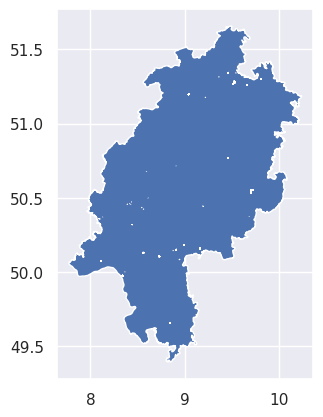

In [3]:
roi = gpd.read_file(path_roi).dissolve(by='erzeugt_am').to_crs("EPSG:3034")

# create buffer zone of 100 km
roi_buffer = roi.buffer(100000) # 100 km 

roi.to_crs("EPSG:4036").plot()

### LST (MODIS) 
data downloaded using Google Earth Engine

- [MODIS](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/modis/)
    - Terra (1999) und Aqua (2002)
    - 10:30 a.m. descending node (Terra)
    - 1:30 p.m. ascending node (Aqua) 

### Ta Raster HOSTRADA (DWD)
- [DWD](https://opendata.dwd.de/climate_environment/CDC/grids_germany/hourly/hostrada/)
    - temporal resolution: 1h (0000-2300)

In [ ]:
data_hostrada = xr.open_mfdataset(
    path_hostrada + "/*.nc",
    parallel=True,
    concat_dim="time",
    combine="nested",
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

data_hostrada.rio.set_spatial_dims("X", "Y")
data_hostrada.rio.set_crs("EPSG:3034")

data_hostrada_roi = data_hostrada.tas.rio.set_crs(data_hostrada.rio.crs).rio.clip(roi_buffer.geometry)
del data_hostrada

data_hostrada_roi

In [ ]:
del data_hostrada_roi # in case it is needed

#### 24 hour Ta

In [ ]:
for i in range(24):
    print(i)
    data_hostrada_roi_time_i_mean = data_hostrada_roi.isel(time = (data_hostrada_roi.time.dt.hour == i )).mean(dim=["time"])
    data_hostrada_roi_time_i_std  = data_hostrada_roi.isel(time = (data_hostrada_roi.time.dt.hour == i )).std(dim=["time"])
    data_hostrada_roi_time_i_90th = data_hostrada_roi.isel(time = (data_hostrada_roi.time.dt.hour == i )).reduce(np.nanpercentile, q=90, dim=["time"])
    export(data_hostrada_roi_time_i_mean,  path_data+"temperature/hostrada/hourly/tas_1hr_HOSTRADA_h"+str(i)+"_mean.tif")
    export(data_hostrada_roi_time_i_std,   path_data+"temperature/hostrada/hourly/tas_1hr_HOSTRADA_h"+str(i)+"_std.tif")
    export(data_hostrada_roi_time_i_90th,  path_data+"temperature/hostrada/hourly/tas_1hr_HOSTRADA_h"+str(i)+"_90th.tif")

#### Tropical Nights

In [ ]:
data_roi_min = data_hostrada_roi.resample(time ='D',skipna=False).min()

# Create a dummy raster with the same spatial dimensions as the data
template_raster = xr.DataArray(np.zeros_like(data_roi_min.isel(time=0)),
                                coords=data_roi_min.isel(time=0).coords)

# Create a mask where the minimum temperature exceeds 20°C
tropical_nights_mask = (data_roi_min > 20).astype(int)

# Replace the values in the dummy raster with the tropical nights count
template_raster.values = tropical_nights_mask.sum(dim='time')

# Clip to ROI
template_raster.rio.set_crs("EPSG:3034")
template_raster.rio.clip(roi.geometry)

# Write the raster to a file
template_raster.rio.to_raster(path_data+"temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_tropical_nights.tif")

#### (Very) Hot Days
##### > 30°C

In [ ]:
data_roi_max = data_hostrada_roi.resample(time ='D',skipna=False).max()

# Create a dummy raster with the same spatial dimensions as your data
template_raster = xr.DataArray(np.zeros_like(data_roi_max.isel(time=0)),
                                coords=data_roi_max.isel(time=0).coords)

# Create a mask where the maximum temperature exceeds 30°C
hot_days_mask = (data_roi_max > 30).astype(int)

# Replace the values in the dummy raster
template_raster.values = hot_days_mask.sum(dim='time')

# Clip to ROI
template_raster.rio.set_crs("EPSG:3034")
template_raster.rio.clip(roi.geometry)

template_raster.rio.to_raster(path_data+"temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_hot_day.tif")

##### > 35°C

In [ ]:
data_roi_max = data_hostrada_roi.resample(time ='D',skipna=False).max()

# Create a dummy raster with the same spatial dimensions as your data
template_raster = xr.DataArray(np.zeros_like(data_roi_max.isel(time=0)),
                                coords=data_roi_max.isel(time=0).coords)

# Create a mask where the maximum temperature exceeds 35°C
very_hot_days_mask = (data_roi_max > 35).astype(int)

# Replace the values in the dummy raster with the tropical nights count
template_raster.values = very_hot_days_mask.sum(dim='time')

# Clip to ROI
template_raster.rio.set_crs("EPSG:3034")
template_raster.rio.clip(roi.geometry)

template_raster.rio.to_raster(path_data+"temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_very_hot_day.tif")

#### Heat Wave

- 3 consecutive days over 90th percentile temperature of last 30 days (or here of all time)
    - e.g.:
        - 90th
            - max: 28.3, min: 18.3, mean: 24.8182667
        - 95th
            - max: 30.6, min 20.4, mean: 27.133
- & temperature above 28°C (https://www.dwd.de/DE/service/lexikon/Functions/glossar.html?lv3=624852&lv2=101094)

- The per-pixel calculations are resource-intensive and time-consuming.

In [22]:
def count_heat_wave(arr):
    # Shape: (Time, Space, Space)
    # change True False to 1 / 0
    # start 1 , end of event -1
    change = dask.array.diff(dask.array.where(arr, 1, 0),axis=0)
    
    # Count number of heatwave
    count = dask.array.where(change==1, 1, 0).sum(axis=0)
    return count

In [ ]:
# Test Function

# Example 3x4x5 array
data = np.array([
    [[False, False, True, True, False], [False, True, True, False, False], [True, True, True, False, False], [False, False, False, False, False]],
    [[False, True, True, False, False], [True, True, True, False, False], [False, False, True, True, True], [True, True, False, False, False]],
    [[True, True, False, False, False], [False, False, False, True, True], [True, False, False, False, False], [False, True, True, True, False]]
])
print(data.shape)

# Convert to a Dask array
arr = data

# Count number of heatwaves
# change True False to 1/ 0
# start 1 , end of event -1
change = dask.array.diff(dask.array.where(arr, 1, 0),axis=0)#.cumsum(axis=0)
count = dask.array.where(change==1, 1, 0).sum(axis=0)

# max_count = count.max(axis=0).compute()

print("Original Data:\n", data)
print(" Count:\n", change.compute())
print(" Count:\n", count.compute())
#print("Max Heatwave Count:\n", max_count)

In [ ]:
data_roi = data_hostrada_roi.sortby('time') # datamust be monotonic for resampling

# get maximum air temperature per day
data_roi_max = data_roi.resample(time ='D',skipna=False).max()

In [ ]:
percentile_90 = data_roi.reduce(np.nanpercentile, q=90, dim=["time"])

print(percentile_90.max())
print(percentile_90.min())
print(percentile_90.mean())

export(percentile_90, path_data + "temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_90th.tif")

In [ ]:
# Create a mask where daily maximum temperature exceeds the 90th percentile
above_percentile_90 = ((data_roi_max > percentile_90) & (data_roi_max >= 28)).astype(int)

# Apply a rolling window of size 3 to find consecutive heat wave days
heat_wave_3_days = above_percentile_90.rolling(time=3).sum() >= 3

# Count the number of heat wave days (with out the first three
heat_wave_count = heat_wave_3_days.sum(dim='time')

# Count the number of unique heat wave events
n_heatwaves = count_heat_wave(heat_wave_3_days)

# Count the number of true heat wave days
n_true_heat_wave_days = n_heatwaves*3+heat_wave_count

In [ ]:
# Create a dummy raster with the same spatial dimensions as your data
template_raster = xr.DataArray(np.zeros_like(data_roi_max.isel(time=0)),
                                coords=data_roi_max.isel(time=0).coords)

# Replace the values in the dummy raster with the count of heat wave events
template_raster.values = n_true_heat_wave_days

# Write the raster to a file
template_raster.rio.set_crs("EPSG:3034")
template_raster.rio.to_raster(path_data + "temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_heat_wave_days_90th_28.tif")

In [ ]:
# Create a dummy raster with the same spatial dimensions as your data
template_raster = xr.DataArray(np.zeros_like(data_roi_max.isel(time=0)),
                                coords=data_roi_max.isel(time=0).coords)

# Replace the values in the dummy raster with the count of heat wave events
template_raster.values = n_heatwaves

# Write the raster to a file
template_raster.rio.set_crs("EPSG:3034")
template_raster.rio.to_raster(path_data + "temperature/hostrada/tas_1hr_HOSTRADA_2011_2020_months-678_heat_wave_events_90th_28.tif")

#### Thermal Comfort Parameters
##### Ta

In [ ]:
data_hostrada = xr.open_mfdataset(
    path_hostrada + "/*.nc",
    parallel=True,
    concat_dim="time",
    combine="nested",
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

data_hostrada.rio.set_spatial_dims("X", "Y")
data_hostrada.rio.set_crs("EPSG:3034")

data_hostrada_Ta_roi = data_hostrada.tas.rio.set_crs(data_hostrada.rio.crs).rio.clip(roi_buffer.geometry) # "EPSG:3034"
del data_hostrada

##### RH

In [ ]:
data_hostrada_RH = xr.open_mfdataset(
    path_hostrada_RH + "/*.nc",
    parallel=True,
    concat_dim="time",
    combine="nested",
    data_vars="minimal",
    coords="minimal",
    compat="override",
)

data_hostrada_RH.rio.set_spatial_dims("X", "Y")
data_hostrada_RH.rio.set_crs("EPSG:3034")

data_hostrada_RH_roi = data_hostrada_RH.hurs.rio.set_crs(data_hostrada_RH.rio.crs).rio.clip(roi_buffer.geometry) # "EPSG:3034"
del data_hostrada_RH

# load only specific temporal subindey
data_hostrada_RH_roi = data_hostrada_RH_roi.sel(time=slice('2011', '2020'))

data_hostrada_RH_roi.rio.set_spatial_dims("X", "Y")
data_hostrada_RH_roi.rio.set_crs("EPSG:3034")

##### Thermal Comfort Parameters

In [ ]:
for h in range(24):
    Ta_mean = data_hostrada_Ta_roi.isel(time = (data_hostrada_Ta_roi.time.dt.hour == h )).mean(dim=["time"])
    RH_mean = data_hostrada_RH_roi.isel(time = (data_hostrada_RH_roi.time.dt.hour == h)).mean(dim=["time"])

    # Based on: https://github.com/CenterForTheBuiltEnvironment/pythermalcomfort/blob/master/pythermalcomfort/models/humidex.py and so on
    HUMIDEX = Ta_mean + 5 / 9 * ((6.112 * 10 ** (7.5 * Ta_mean / (237.7 + Ta_mean)) * RH_mean / 100) - 10)
    export(HUMIDEX, path_data+"temperature/hostrada/thermal_comfort/HUMIDEX_HOSTRADA_2011_2020_678_h"+str("{:02d}".format(h))+"_mean_buffer.tif")

    hi = -8.784695 + 1.61139411 * Ta_mean + 2.338549 * RH_mean - 0.14611605 * Ta_mean * RH_mean
    hi += -1.2308094 * 10**-2 * Ta_mean**2 - 1.6424828 * 10**-2 * RH_mean**2
    hi += 2.211732 * 10**-3 * Ta_mean**2 * RH_mean + 7.2546 * 10**-4 * Ta_mean * RH_mean**2
    hi += -3.582 * 10**-6 * Ta_mean**2 * RH_mean**2

    HEAT_INDEX = np.round(hi,1)
    export(HEAT_INDEX,  path_data+"temperature/hostrada/thermal_comfort/HEAT_INDEX_HOSTRADA_2011_2020_678_h"+str("{:02d}".format(h))+"_mean_buffer.tif")

    DISCOMFORT_INDEX = Ta_mean  - 0.55 * (1 - 0.01 * RH_mean ) * (Ta_mean  - 14.5)
    export(DISCOMFORT_INDEX,  path_data+"temperature/hostrada/thermal_comfort/DISCOMFORT_INDEX_HOSTRADA_2011_2020_678_h"+str("{:02d}".format(h))+"_mean_buffer.tif")


# Calculation of dT 

In [27]:
# might need to change the paths
def write_yaml(path_LST, path_yaml = './params.yaml'):
    with open(path_yaml, 'w') as file:
    
        file.write('threshold_urban_areas: null\n')
        file.write('threshold_elevation: 100\n')
        file.write('threshold_pixels: 30\n')
        file.write('buffer: 100\n')
        file.write('path_urban_areas: \'/mnt/mountpoint/wkdir/hesse-uhi/data/other/urban_areas_corine.tif\'\n')
        file.write('path_elevation: \'/mnt/mountpoint/wkdir/hesse-uhi/data/other/dem.tif\'\n')
        file.write('path_aspect: \'/mnt/mountpoint/wkdir/hesse-uhi/data/other/aspect.tif\'\n')
        file.write('path_LST: '+path_LST+'\n')
        file.write('path_roi: \'/mnt/mountpoint/wkdir/hesse-uhi/data/other/roi_1000_buffer.tif\'\n')

## for the MODIS dataset

In [ ]:
for file in os.listdir(path_data+'temperature/modis/'):
    if '.tif' in file:
        path_in = os.path.join(path_data+'temperature/modis/', file)
        print(path_in)

        write_yaml(path_in)

        %run ./getDT_atkis.py

## for the HOSTRADA dataset

In [ ]:
for file in os.listdir(path_data+'temperature/hostrada/hourly/'):
    # Check if the file has a .tif extension
    if file.endswith('.tif'):
        path_in = os.path.join(path_data+'temperature/hostrada/hourly/', file)
        print(path_in)
    
        write_yaml(path_in)
    
        %run ./getDT_atkis.py

## Thermal Comofort Dataset
change paths as needed

In [ ]:
for file in os.listdir(path_data+'temperature/klimanalyse/'):
    # Check if the file has a .tif extension
    if file.endswith('PET_1000.tif'):
        path_in = os.path.join(path_data+'temperature/klimanalyse/', file)
        print(path_in)
    
        write_yaml(path_in)
    
        %run ./getDT_atkis.py

## Crop to ROI

- adjust paths / files as necessary

In [9]:
Hesse = gpd.read_file(path_roi).dissolve(by='erzeugt_am').to_crs("EPSG:25832")

In [ ]:
for file in os.listdir(path_data+'temperature/hostrada/heatwave/'):

    if file.endswith('25832.tif'):
        print(file)
        path_in = os.path.join((path_data+'temperature/hostrada/heatwave/'), file)

    
        raster_data = rioxarray.open_rasterio(path_in)
    
        raster_data_clipped = raster_data.rio.clip(Hesse.geometry, Hesse.crs)
    
        # write to file
        raster_data_clipped.rio.to_raster(path_data+'temperature/hostrada/heatwave/'+file.split(".")[0]+"_clip.tif")


In [ ]:
for file in os.listdir(path_data+'temperature/modis/DT/'):

    if file.endswith('.tif'):
        print(file)
        path_in = os.path.join((path_data+'temperature/modis/DT/'), file)

    
        raster_data = rioxarray.open_rasterio(path_in)
    
        raster_data_clipped = raster_data.rio.clip(Hesse.geometry, Hesse.crs)
    
        # write to file
        raster_data_clipped.rio.to_raster(path_data+'temperature/modis/DT/'+file.split(".")[0]+"_clip.tif")

In [ ]:
for file in os.listdir(path_data+'temperature/klimanalyse/DT/'):

    if file.endswith('.tif'):
        print(file)
        path_in = os.path.join((path_data+'temperature/klimanalyse/DT/'), file)

    
        raster_data = rioxarray.open_rasterio(path_in)
    
        raster_data_clipped = raster_data.rio.clip(Hesse.geometry, Hesse.crs)
    
        # write to file
        raster_data_clipped.rio.to_raster(path_data+'temperature/klimanalyse/DT/'+file.split(".")[0]+"_clip.tif")